# Level 3: BSTS + Synthetic Control
### *Regression-based SC — donors fix both Level 2 failure modes*

**Method clarification:** This is not classical Abadie-style Synthetic Control.
Organic demand channels are passed as covariates into CausalImpact (BSTS with
contemporaneous controls). Spike-and-slab priors perform Bayesian variable
selection over the donor set. It is best understood as Bayesian regression
with time-series structure, not pure SC.

**Why this fixes Level 2 failures:**

1. **Trend shift:** All donors share the same growth acceleration. Their
   co-movement with PS in the pre-period already embeds the trend —
   no extrapolation needed.

2. **Under-estimated BF spike:** Donor channels also spike during BF
   (organic demand: +35-73%). Those elevated covariate values at the BF
   moment directly anchor the counterfactual at the actual 2025 level —
   not diluted across a seasonal bin.

**Key assumptions (see writeup for full discussion):**
Donor exogeneity (donors not affected by PS campaigns), no interference (SUTVA),
contemporaneous relationships, stable pre/post relationships, sufficient pre-period fit,
donor independence (multicollinearity mitigated by spike-and-slab priors).

**Email excluded:** Runs its own BF campaigns — not an organic demand proxy.

**Two versions tested:**
- v01: 23-month pre-period (Jan 2024 - Nov 2025, includes BF 2024)
- v02: 7-month pre-period (May-Nov 2025, no prior year data)

**Ground truth: 1,340 USD/day = 71.6% of Nov pre-BF baseline**

R required: https://cran.r-project.org/bin/macosx/

In [1]:
import sys, subprocess
sys.path.append('../src')
subprocess.run(['pip','install','rpy2','--break-system-packages','-q'], check=False)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')
from pathlib import Path

import rpy2.robjects as ro
from rpy2.robjects import pandas2ri
from rpy2.robjects.conversion import localconverter

from utils import (
    get_treated_series, set_style, save_figure,
    add_intervention_band, add_trend_shift_line,
    format_date_axis, usd_formatter, compute_bf_effect,
    INTERVENTION_START, INTERVENTION_END,
    TREATED_CHANNEL, DONOR_CHANNELS, PALETTE, DATA_DIR
)
from generate_data import generate_dataset

set_style()
df, gt = generate_dataset(seed=42, data_dir=DATA_DIR)
ts     = get_treated_series(df)
TRUE_DAILY = gt['true_increment_usd']

print(f'Ground truth: {TRUE_DAILY:,.0f} USD/day  ({gt["true_increment_pct"]}%)')
print(f'Donor channels: {DONOR_CHANNELS}')
print('Email excluded: runs own BF campaigns')

Saved: dataset.csv  (4,386 rows)
Ground truth: 1,340 USD/day  (71.6%)
Donor channels: ['Organic Search', 'Direct', 'Referral', 'Social']
Email excluded: runs own BF campaigns


## 0. Install R packages (run once)

In [ ]:
ro.r('''
pkgs <- c("data.table","CausalImpact","zoo","scales","bsts")
for (pkg in pkgs) {
    if (!requireNamespace(pkg, quietly=TRUE))
        install.packages(pkg, repos="https://cran.r-project.org", quiet=TRUE)
    suppressPackageStartupMessages(library(pkg, character.only=TRUE))
}
cat("R packages ready\n")
''')

## 1. Prepare data

In [2]:
panel = df.pivot_table(index='date', columns='channel', values='revenue_usd').reset_index()
panel.columns.name = None
panel.columns = [c.replace(' ', '_') for c in panel.columns]
panel['date'] = panel['date'].dt.strftime('%Y-%m-%d')

treated_r    = TREATED_CHANNEL.replace(' ', '_')
covariates_r = [c.replace(' ', '_') for c in DONOR_CHANNELS]

output_path  = Path('../outputs/bsts_sc').resolve()
output_path.mkdir(parents=True, exist_ok=True)
wrapper_path = Path('../src/causal_impact_wrapper.R').resolve()
ro.r(f'source("{wrapper_path}")')

with localconverter(ro.default_converter + pandas2ri.converter):
    ro.globalenv['panel_r'] = ro.conversion.py2rpy(panel)
ro.globalenv['treated_r']    = treated_r
ro.globalenv['covariates_r'] = ro.StrVector(covariates_r)
ro.globalenv['outpath_r']    = str(output_path) + '/'
print(f'Treated: {treated_r}  |  Donors: {covariates_r}')

Treated: Paid_Search  |  Donors: ['Organic_Search', 'Direct', 'Referral', 'Social']


## 2. Run v01 — 23-month pre-period

Jan 2024 – Nov 2025. Includes BF 2024 and the full trend-shift period.
This is the baseline specification.

In [3]:
print('Running v01 (23-month pre-period)...')
ro.r('''
result_v01 <- causal_impact_with_covariates(
    indata=panel_r,
    pre_period=as.Date(c("2024-01-01","2025-11-26")),
    post_period=as.Date(c("2025-11-27","2025-12-31")),
    reversion_period=as.Date(c("2025-12-03","2025-12-31")),
    time_var="date", time_var_format="%Y-%m-%d",
    treated=treated_r, covariates=covariates_r,
    niter=1000, nseasons=7, trend_model="local_level",
    ver="v01", note="23-month pre-period, organic demand donors",
    outpath=outpath_r)
cat("v01 done\n")
print(summary(result_v01$impact))
''')
print('v01 complete.')

Running v01 (23-month pre-period)...


R callback write-console: Pre-period: MAPE=10.0%  WMAPE=8.9%
  
R callback write-console: Reversion:  MAPE=8.9%  WMAPE=8.9%
  
R callback write-console: Chart warning: could not find function "scale_y_continuous"
  


v01 done
Posterior inference {CausalImpact}

                         Average        Cumulative    
Actual                   2364           82730         
Prediction (s.d.)        2107 (43)      73759 (1494)  
95% CI                   [2026, 2197]   [70920, 76894]
                                                      
Absolute effect (s.d.)   256 (43)       8971 (1494)   
95% CI                   [167, 337]     [5836, 11810] 
                                                      
Relative effect (s.d.)   12% (2.3%)     12% (2.3%)    
95% CI                   [7.6%, 17%]    [7.6%, 17%]   

Posterior tail-area probability p:   0.00124
Posterior probability of an effect:  99.87608%

For more details, type: summary(impact, "report")

NULL
v01 complete.


## 3. Run v02 — 7-month pre-period

May – Nov 2025. Entirely within the trend-shift window — no 2024 data at all.
Tests whether donor co-movement compensates for very short history.
If pre-period MAPE is acceptable, it confirms that co-movement quality
matters more than pre-period length.

In [5]:
print('Running v02 (7-month pre-period)...')
ro.r('''
result_v02 <- causal_impact_with_covariates(
    indata=panel_r,
    pre_period=as.Date(c("2025-05-01","2025-11-26")),
    post_period=as.Date(c("2025-11-27","2025-12-31")),
    reversion_period=as.Date(c("2025-12-03","2025-12-31")),
    time_var="date", time_var_format="%Y-%m-%d",
    treated=treated_r, covariates=covariates_r,
    niter=1000, nseasons=7, trend_model="local_level",
    ver="v02", note="3-month pre-period (May-Nov 2025), no prior year data",
    outpath=outpath_r)
cat("v02 done\n")
print(summary(result_v02$impact))
''')
print('v02 complete.')

Running v02 (7-month pre-period)...


R callback write-console: Pre-period: MAPE=9.2%  WMAPE=8.3%
  
R callback write-console: Reversion:  MAPE=9.1%  WMAPE=9.1%
  
R callback write-console: Chart warning: could not find function "scale_y_continuous"
  


v02 done
Posterior inference {CausalImpact}

                         Average        Cumulative    
Actual                   2364           82730         
Prediction (s.d.)        2095 (49)      73329 (1721)  
95% CI                   [2001, 2192]   [70032, 76730]
                                                      
Absolute effect (s.d.)   269 (49)       9401 (1721)   
95% CI                   [171, 363]     [6000, 12698] 
                                                      
Relative effect (s.d.)   13% (2.7%)     13% (2.7%)    
95% CI                   [7.8%, 18%]    [7.8%, 18%]   

Posterior tail-area probability p:   0.00104
Posterior probability of an effect:  99.89616%

For more details, type: summary(impact, "report")

NULL
v02 complete.


## 4. Extract results

In [6]:
def extract_series(r_name):
    with localconverter(ro.default_converter + pandas2ri.converter):
        raw = ro.conversion.rpy2py(ro.r(f'as.data.frame({r_name}$impact$series)'))
    def gc(cols):
        for c in cols:
            if c in raw.columns: return raw[c].values.astype(float)
        raise KeyError(f'{cols} not in {list(raw.columns)}')
    res = pd.DataFrame({
        'actual':       gc(['response','actual']),
        'predicted':    gc(['point.pred','predicted','point_pred']),
        'lower_95':     gc(['point.pred.lower','point_pred_lower']),
        'upper_95':     gc(['point.pred.upper','point_pred_upper']),
        'point_effect': gc(['point.effect','point_effect']),
    })
    res.index = ts.index[-len(res):]
    return res

res_v01 = extract_series('result_v01')
res_v02 = extract_series('result_v02')

bf_v01 = compute_bf_effect(res_v01['actual'], res_v01['predicted'])
bf_v02 = compute_bf_effect(res_v02['actual'], res_v02['predicted'])

print(f'Ground truth:    {TRUE_DAILY:,.0f} USD/day')
print(f'v01 (23-month):  {bf_v01["daily_effect"]:,.0f} USD/day  ({(bf_v01["daily_effect"]/TRUE_DAILY-1)*100:+.0f}%)')
print(f'v02 (7-month):   {bf_v02["daily_effect"]:,.0f} USD/day  ({(bf_v02["daily_effect"]/TRUE_DAILY-1)*100:+.0f}%)')

sc_v01_effect = bf_v01['daily_effect']
sc_v02_effect = bf_v02['daily_effect']

Ground truth:    1,340 USD/day
v01 (23-month):  1,299 USD/day  (-3%)
v02 (7-month):   1,382 USD/day  (+3%)


## 5. Validation — Pre-period fit diagnostics

The SC estimate is only credible if the counterfactual tracks Paid Search well
during the pre-period. We check:
- **MAPE** (mean absolute percentage error) — overall fit quality
- **Bias** — systematic over- or under-prediction (MAPE can look good with cancelling errors)
- **Autocorrelation** — serial correlation in residuals indicates a structural pattern missed

Threshold: MAPE below 10-15% is acceptable. Bias close to zero. No strong autocorrelation.
A failed check here means the counterfactual is misspecified before it even reaches BF.

In [7]:
from scipy import stats as scipy_stats

def pre_period_diagnostics(res, label, pre_start=None):
    pre_mask = res.index < INTERVENTION_START
    if pre_start:
        pre_mask = pre_mask & (res.index >= pre_start)
    actual    = res['actual'][pre_mask].values
    predicted = res['predicted'][pre_mask].values
    residuals = actual - predicted

    mape      = np.mean(np.abs(residuals / actual)) * 100
    bias      = residuals.mean()                        # systematic over/under prediction
    bias_pct  = bias / actual.mean() * 100
    rmse      = np.sqrt(np.mean(residuals**2))

    # Durbin-Watson statistic: ~2 = no autocorrelation, <1 or >3 = concern
    dw = np.sum(np.diff(residuals)**2) / np.sum(residuals**2)

    print(f'--- {label} pre-period diagnostics ---')
    print(f'  MAPE:             {mape:.1f}%   (threshold: <15%)')
    print(f'  Bias:             {bias:+.0f} USD/day ({bias_pct:+.1f}%)   (target: ~0)')
    print(f'  RMSE:             {rmse:.0f} USD/day')
    print(f'  Durbin-Watson:    {dw:.2f}   (target: ~2.0, concern: <1 or >3)')
    status = 'PASS' if mape < 15 and abs(bias_pct) < 5 and 1 < dw < 3 else 'REVIEW'
    print(f'  Overall:          {status}')
    return {'mape': mape, 'bias': bias, 'bias_pct': bias_pct, 'rmse': rmse, 'dw': dw}

diag_v01 = pre_period_diagnostics(res_v01, 'v01 (23-month)')
print()
diag_v02 = pre_period_diagnostics(res_v02, 'v02 (7-month)', pre_start='2025-05-01')

--- v01 (23-month) pre-period diagnostics ---
  MAPE:             10.0%   (threshold: <15%)
  Bias:             -0 USD/day (-0.0%)   (target: ~0)
  RMSE:             160 USD/day
  Durbin-Watson:    1.64   (target: ~2.0, concern: <1 or >3)
  Overall:          PASS

--- v02 (7-month) pre-period diagnostics ---
  MAPE:             9.2%   (threshold: <15%)
  Bias:             +1 USD/day (+0.0%)   (target: ~0)
  RMSE:             180 USD/day
  Durbin-Watson:    1.59   (target: ~2.0, concern: <1 or >3)
  Overall:          PASS


Saved: 03a_pre_period_fit.png


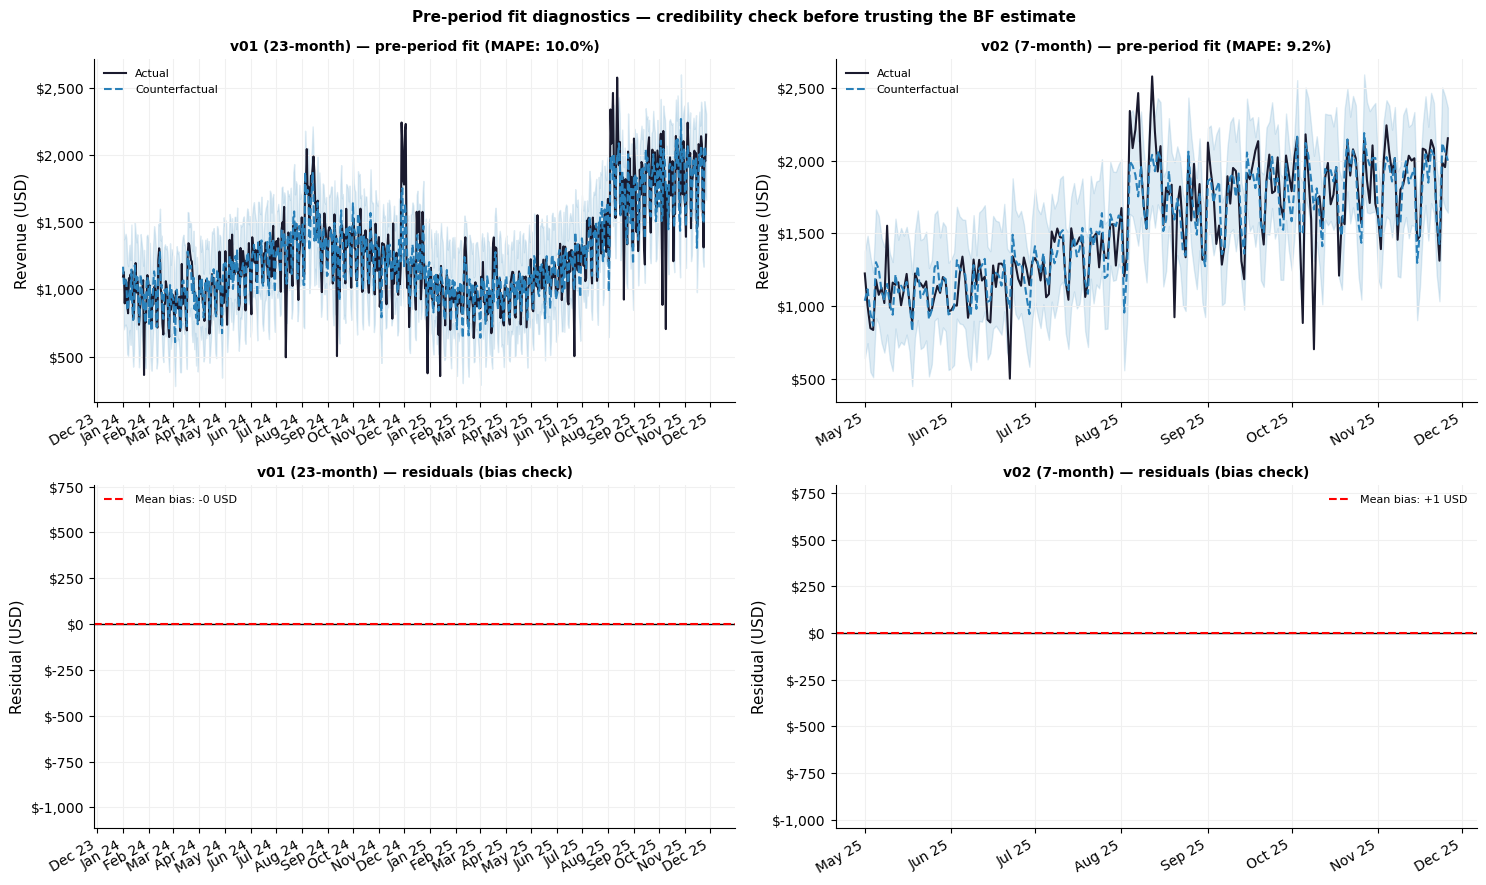

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(15, 9))

for col, res, label, pre_start in [
    (0, res_v01, 'v01 (23-month)', pd.Timestamp('2024-01-01')),
    (1, res_v02, 'v02 (7-month)',  pd.Timestamp('2025-05-01')),
]:
    pre_mask = (res.index >= pre_start) & (res.index < INTERVENTION_START)
    pre_dates = np.array(res.index[pre_mask])
    actual    = res['actual'][pre_mask].values
    predicted = res['predicted'][pre_mask].values
    residuals = actual - predicted

    # Panel top: actual vs predicted in pre-period
    ax = axes[0, col]
    ax.plot(pre_dates, actual,    color=PALETTE['actual'],  lw=1.5, label='Actual')
    ax.plot(pre_dates, predicted, color=PALETTE['level3'],  lw=1.5, ls='--', label='Counterfactual')
    ax.fill_between(pre_dates,
                    res['lower_95'][pre_mask].values,
                    res['upper_95'][pre_mask].values,
                    color=PALETTE['level3'], alpha=0.15)
    format_date_axis(ax)
    mape = np.mean(np.abs(residuals / actual)) * 100
    ax.set_title(f'{label} — pre-period fit (MAPE: {mape:.1f}%)', fontsize=10)
    ax.set_ylabel('Revenue (USD)')
    ax.yaxis.set_major_formatter(usd_formatter())
    ax.legend(fontsize=8)

    # Panel bottom: residuals
    ax = axes[1, col]
    ax.bar(pre_dates, residuals,
           color=[PALETTE['level1'] if r < 0 else PALETTE['level3'] for r in residuals],
           alpha=0.7, width=1)
    ax.axhline(0, color='black', lw=1)
    ax.axhline(residuals.mean(), color='red', lw=1.5, ls='--',
               label=f'Mean bias: {residuals.mean():+.0f} USD')
    format_date_axis(ax)
    ax.set_title(f'{label} — residuals (bias check)', fontsize=10)
    ax.set_ylabel('Residual (USD)')
    ax.yaxis.set_major_formatter(usd_formatter())
    ax.legend(fontsize=8)

plt.suptitle('Pre-period fit diagnostics — credibility check before trusting the BF estimate',
             fontsize=11, fontweight='bold')
plt.tight_layout()
save_figure(fig, '03a_pre_period_fit')
plt.show()

## 6. Validation — Placebo test

Apply the same model to a pseudo-intervention in the pre-period where no
intervention occurred. If the method finds a large effect there, it is
detecting noise rather than signal.

We use Sep 5, 2025 as the placebo date — well within the pre-period,
after the trend shift has started, with no campaign event.
A credible model should show near-zero effect.

In [9]:
PLACEBO_DATE = '2025-09-05'

ro.globalenv['placebo_s'] = PLACEBO_DATE
ro.globalenv['placebo_e'] = '2025-11-26'   # run up to actual pre-period end

print(f'Running placebo test (pseudo-intervention at {PLACEBO_DATE})...')
ro.r('''
result_placebo <- causal_impact_with_covariates(
    indata=panel_r,
    pre_period=as.Date(c("2024-01-01", "2025-09-04")),
    post_period=as.Date(c(placebo_s, placebo_e)),
    reversion_period=as.Date(c(placebo_s, placebo_e)),
    time_var="date", time_var_format="%Y-%m-%d",
    treated=treated_r, covariates=covariates_r,
    niter=1000, nseasons=7, trend_model="local_level",
    ver="placebo", note="placebo test — pseudo-intervention Sep 5 2025",
    outpath=outpath_r)
cat("Placebo done\n")
print(summary(result_placebo$impact))
''')
print('Placebo complete.')

Running placebo test (pseudo-intervention at 2025-09-05)...


R callback write-console: Pre-period: MAPE=10.2%  WMAPE=9.3%
  
R callback write-console: Reversion:  MAPE=10.5%  WMAPE=8.3%
  
R callback write-console: Chart warning: could not find function "scale_y_continuous"
  


Placebo done
Posterior inference {CausalImpact}

                         Average          Cumulative      
Actual                   1792             148753          
Prediction (s.d.)        1895 (36)        157284 (2996)   
95% CI                   [1825, 1966]     [151474, 163175]
                                                          
Absolute effect (s.d.)   -103 (36)        -8531 (2996)    
95% CI                   [-174, -33]      [-14422, -2721] 
                                                          
Relative effect (s.d.)   -5.4% (1.8%)     -5.4% (1.8%)    
95% CI                   [-8.8%, -1.8%]   [-8.8%, -1.8%]  

Posterior tail-area probability p:   0.00523
Posterior probability of an effect:  99.47699%

For more details, type: summary(impact, "report")

NULL
Placebo complete.


Placebo effect (pseudo-intervention 2025-09-05): -103 USD/day (-5.4%)
True BF effect (v01):                               +1299 USD/day
Ratio placebo/true:                                  0.08

PASS: Placebo effect is small relative to true effect — model is not detecting noise.
Saved: 03b_placebo_test.png


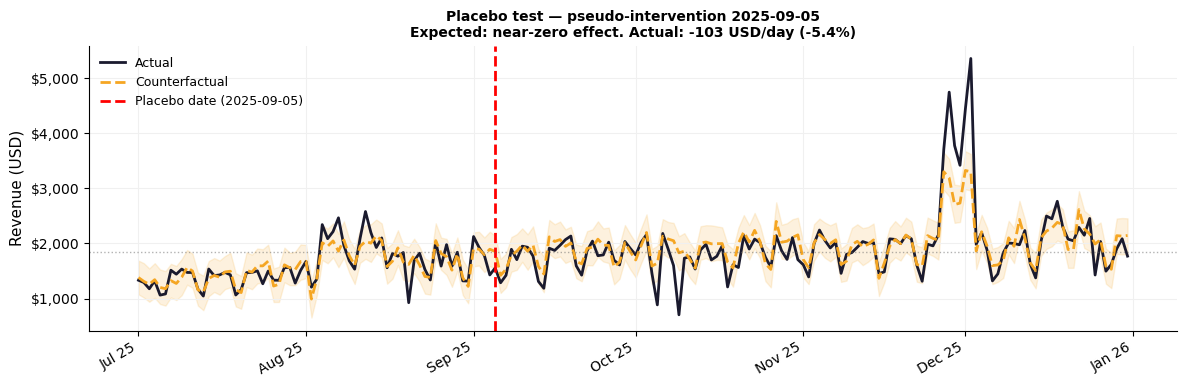

In [10]:
res_placebo = extract_series('result_placebo')

# Effect during placebo post-period
plac_mask = (res_placebo.index >= pd.Timestamp(PLACEBO_DATE)) & \
            (res_placebo.index <= pd.Timestamp('2025-11-26'))
plac_effect = (res_placebo['actual'] - res_placebo['predicted'])[plac_mask].mean()
plac_pct    = plac_effect / res_placebo['predicted'][plac_mask].mean() * 100

print(f'Placebo effect (pseudo-intervention {PLACEBO_DATE}): {plac_effect:+.0f} USD/day ({plac_pct:+.1f}%)')
print(f'True BF effect (v01):                               {bf_v01["daily_effect"]:+.0f} USD/day')
print(f'Ratio placebo/true:                                  {abs(plac_effect/bf_v01["daily_effect"]):.2f}')
print()
if abs(plac_pct) < 10:
    print('PASS: Placebo effect is small relative to true effect — model is not detecting noise.')
else:
    print('REVIEW: Placebo effect is large — model may be picking up spurious signal.')

# Plot
fig, ax = plt.subplots(figsize=(12, 4))
zm = np.array(res_placebo.index >= '2025-07-01')
zd = np.array(res_placebo.index[zm])
ax.plot(zd, res_placebo['actual'].values[zm],    color=PALETTE['actual'], lw=2, label='Actual')
ax.plot(zd, res_placebo['predicted'].values[zm], color=PALETTE['level2'], lw=2, ls='--',
        label='Counterfactual')
ax.fill_between(zd, res_placebo['lower_95'].values[zm], res_placebo['upper_95'].values[zm],
                color=PALETTE['level2'], alpha=0.15)
ax.axvline(pd.Timestamp(PLACEBO_DATE), color='red', lw=2, ls='--',
           label=f'Placebo date ({PLACEBO_DATE})')
ax.axhline(res_placebo['predicted'].values[zm].mean(), color=PALETTE['annotation'],
           lw=1, ls=':', alpha=0.5)
format_date_axis(ax)
ax.set_title(f'Placebo test — pseudo-intervention {PLACEBO_DATE}\n'
             f'Expected: near-zero effect. Actual: {plac_effect:+.0f} USD/day ({plac_pct:+.1f}%)',
             fontsize=10)
ax.set_ylabel('Revenue (USD)')
ax.yaxis.set_major_formatter(usd_formatter())
ax.legend(fontsize=9)
plt.tight_layout()
save_figure(fig, '03b_placebo_test')
plt.show()

## 7. Validation — Sensitivity to donor set

Re-run v01 excluding each donor in turn. A robust estimate should be
stable when any single donor is removed. Large swings indicate unstable
weights — the estimate depends too heavily on one channel.

In [11]:
sensitivity_results = {}

for drop_donor in DONOR_CHANNELS:
    reduced = [c.replace(' ','_') for c in DONOR_CHANNELS if c != drop_donor]
    ro.globalenv['reduced_r'] = ro.StrVector(reduced)
    ro.globalenv['drop_label'] = drop_donor.replace(' ','_')

    ro.r('''
    lbl <- paste0("sens_drop_", drop_label)
    result_sens <- causal_impact_with_covariates(
        indata=panel_r,
        pre_period=as.Date(c("2024-01-01","2025-11-26")),
        post_period=as.Date(c("2025-11-27","2025-12-31")),
        reversion_period=as.Date(c("2025-12-03","2025-12-31")),
        time_var="date", time_var_format="%Y-%m-%d",
        treated=treated_r, covariates=reduced_r,
        niter=500, nseasons=7, trend_model="local_level",
        ver=lbl, note=paste0("sensitivity: dropped ", drop_label),
        outpath=outpath_r)
    assign(paste0("result_", lbl), result_sens)
    ''')

    r_name = f'result_sens_drop_{drop_donor.replace(" ","_")}'
    try:
        res_s  = extract_series('result_sens')
        bf_s   = compute_bf_effect(res_s['actual'], res_s['predicted'])
        sensitivity_results[drop_donor] = bf_s['daily_effect']
    except Exception as e:
        sensitivity_results[drop_donor] = None
        print(f'  {drop_donor}: extraction failed — {e}')

print(f'\nSensitivity analysis — BF effect when each donor is excluded:')
print(f'{"Dropped donor":<22} {"Estimate":>12}  {"vs v01":>8}  {"vs true":>8}')
print('-' * 56)
print(f'{"None (full v01)":<22} {bf_v01["daily_effect"]:>10,.0f}  {0:>+7.0f}%  {(bf_v01["daily_effect"]/TRUE_DAILY-1)*100:>+7.0f}%')
for donor, est in sensitivity_results.items():
    if est is not None:
        delta_v01 = (est / bf_v01['daily_effect'] - 1) * 100
        delta_true= (est / TRUE_DAILY - 1) * 100
        print(f'  Drop {donor:<17} {est:>10,.0f}  {delta_v01:>+7.0f}%  {delta_true:>+7.0f}%')

max_swing = max(abs(v/bf_v01['daily_effect']-1)*100
                for v in sensitivity_results.values() if v is not None)
print(f'\nMax swing vs v01: {max_swing:.0f}%')
if max_swing < 20:
    print('PASS: Estimate is stable across donor variations.')
else:
    print('REVIEW: Estimate changes substantially when a donor is dropped — weights may be unstable.')

R callback write-console: Pre-period: MAPE=10.3%  WMAPE=9.2%
  
R callback write-console: Reversion:  MAPE=10.4%  WMAPE=10.4%
  
R callback write-console: Chart warning: could not find function "scale_y_continuous"
  
R callback write-console: In addition:   
R callback write-console: Warning message:
  
R callback write-console: In FormatInputForConstructModel(data, model.args) :  
R callback write-console: 
   
R callback write-console:  Results potentially inaccurate. Consider using more MCMC samples.
  
R callback write-console: Pre-period: MAPE=10.6%  WMAPE=9.5%
  
R callback write-console: Reversion:  MAPE=8.6%  WMAPE=8.5%
  
R callback write-console: Chart warning: could not find function "scale_y_continuous"
  
R callback write-console: In addition:   
R callback write-console: Warning message:
  
R callback write-console: In FormatInputForConstructModel(data, model.args) :  
R callback write-console: 
   
R callback write-console:  Results potentially inaccurate. Consider usin


Sensitivity analysis — BF effect when each donor is excluded:
Dropped donor              Estimate    vs v01   vs true
--------------------------------------------------------
None (full v01)             1,299       +0%       -3%
  Drop Organic Search         1,524      +17%      +14%
  Drop Direct                 1,442      +11%       +8%
  Drop Referral               1,297       -0%       -3%
  Drop Social                 1,356       +4%       +1%

Max swing vs v01: 17%
PASS: Estimate is stable across donor variations.


## 8. Uncertainty — Posterior credible intervals

The BSTS posterior produces a full distribution over the causal effect.
Point estimates alone are not actionable — the credible interval width
relative to the ROI decision threshold determines whether the estimate
is decision-grade.

Rule of thumb: if the 95% CI excludes zero and the lower bound
still exceeds the campaign cost, the estimate supports a positive ROI decision.

In [12]:
def uncertainty_summary(res, bf_effect, label):
    bf_mask = (res.index >= INTERVENTION_START) & (res.index <= INTERVENTION_END)
    actual  = res['actual'][bf_mask].values
    pred    = res['predicted'][bf_mask].values
    lo      = res['lower_95'][bf_mask].values
    hi      = res['upper_95'][bf_mask].values

    # Daily gap distribution
    gap_mean = (actual - pred).mean()
    gap_lo   = (actual - hi).mean()   # conservative: actual minus upper bound of counterfactual
    gap_hi   = (actual - lo).mean()   # generous:     actual minus lower bound of counterfactual

    print(f'--- {label} uncertainty ---')
    print(f'  Point estimate:      {gap_mean:,.0f} USD/day')
    print(f'  95% CI lower bound:  {gap_lo:,.0f} USD/day')
    print(f'  95% CI upper bound:  {gap_hi:,.0f} USD/day')
    print(f'  CI width:            {gap_hi - gap_lo:,.0f} USD/day')
    print(f'  CI excludes zero:    {"YES" if gap_lo > 0 else "NO"}')
    print(f'  True value in CI:    {"YES" if gap_lo <= TRUE_DAILY <= gap_hi else "NO"}')
    return gap_lo, gap_hi

lo_v01, hi_v01 = uncertainty_summary(res_v01, bf_v01, 'v01 (23-month)')
print()
lo_v02, hi_v02 = uncertainty_summary(res_v02, bf_v02, 'v02 (7-month)')

--- v01 (23-month) uncertainty ---
  Point estimate:      1,299 USD/day
  95% CI lower bound:  966 USD/day
  95% CI upper bound:  1,635 USD/day
  CI width:            669 USD/day
  CI excludes zero:    YES
  True value in CI:    YES

--- v02 (7-month) uncertainty ---
  Point estimate:      1,382 USD/day
  95% CI lower bound:  974 USD/day
  95% CI upper bound:  1,780 USD/day
  CI width:            806 USD/day
  CI excludes zero:    YES
  True value in CI:    YES


Saved: 03c_uncertainty.png


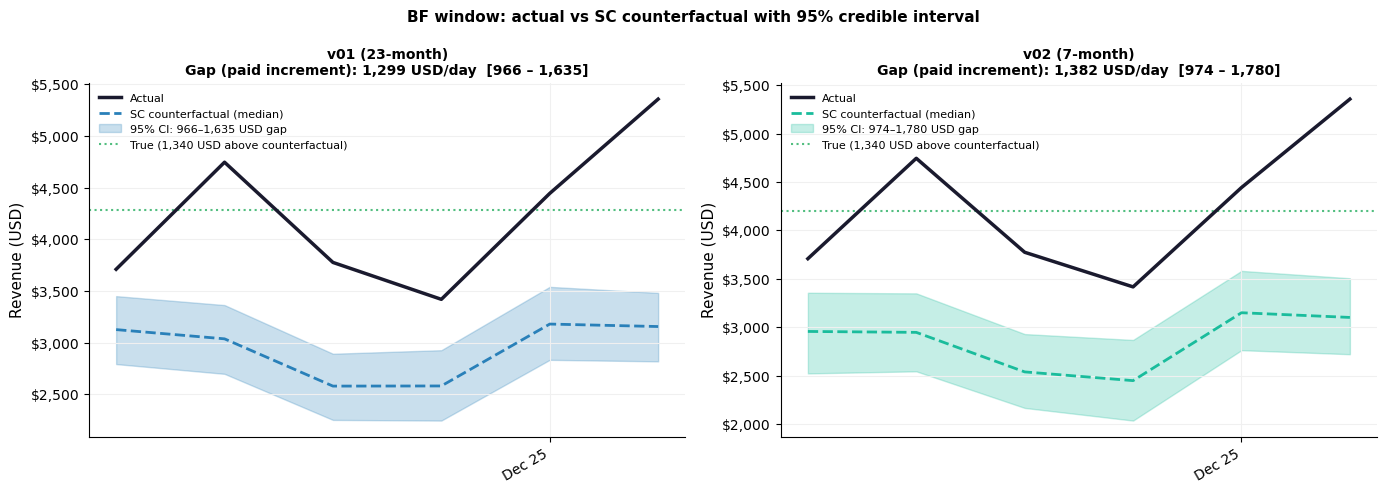

In [13]:
# Visualise posterior distribution of daily effect during BF window
# Extract posterior samples of cumulative effect

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, res, lo, hi, label, color in [
    (axes[0], res_v01, lo_v01, hi_v01, 'v01 (23-month)', PALETTE['level3']),
    (axes[1], res_v02, lo_v02, hi_v02, 'v02 (7-month)',  '#1abc9c'),
]:
    bf_mask = (res.index >= INTERVENTION_START) & (res.index <= INTERVENTION_END)
    dates   = np.array(res.index[bf_mask])
    actual  = res['actual'][bf_mask].values
    pred    = res['predicted'][bf_mask].values
    lo_cf   = res['lower_95'][bf_mask].values
    hi_cf   = res['upper_95'][bf_mask].values

    ax.plot(dates, actual, color=PALETTE['actual'],  lw=2.5, label='Actual', zorder=4)
    ax.plot(dates, pred,   color=color, lw=2, ls='--', label='SC counterfactual (median)', zorder=3)
    ax.fill_between(dates, lo_cf, hi_cf, color=color, alpha=0.25,
                    label=f'95% CI: {lo:,.0f}–{hi:,.0f} USD gap')
    ax.axhline(TRUE_DAILY + pred.mean(), color=PALETTE['truth'], lw=1.5, ls=':',
               label=f'True ({TRUE_DAILY:,.0f} USD above counterfactual)', alpha=0.8)
    format_date_axis(ax)
    ax.set_title(f'{label}\nGap (paid increment): {(actual-pred).mean():,.0f} USD/day  '
                 f'[{lo:,.0f} – {hi:,.0f}]', fontsize=10)
    ax.set_ylabel('Revenue (USD)')
    ax.yaxis.set_major_formatter(usd_formatter())
    ax.legend(fontsize=8)

plt.suptitle('BF window: actual vs SC counterfactual with 95% credible interval',
             fontsize=11, fontweight='bold')
plt.tight_layout()
save_figure(fig, '03c_uncertainty')
plt.show()

## 9. Main results — counterfactual and gap

Saved: 03d_bsts_sc_results.png


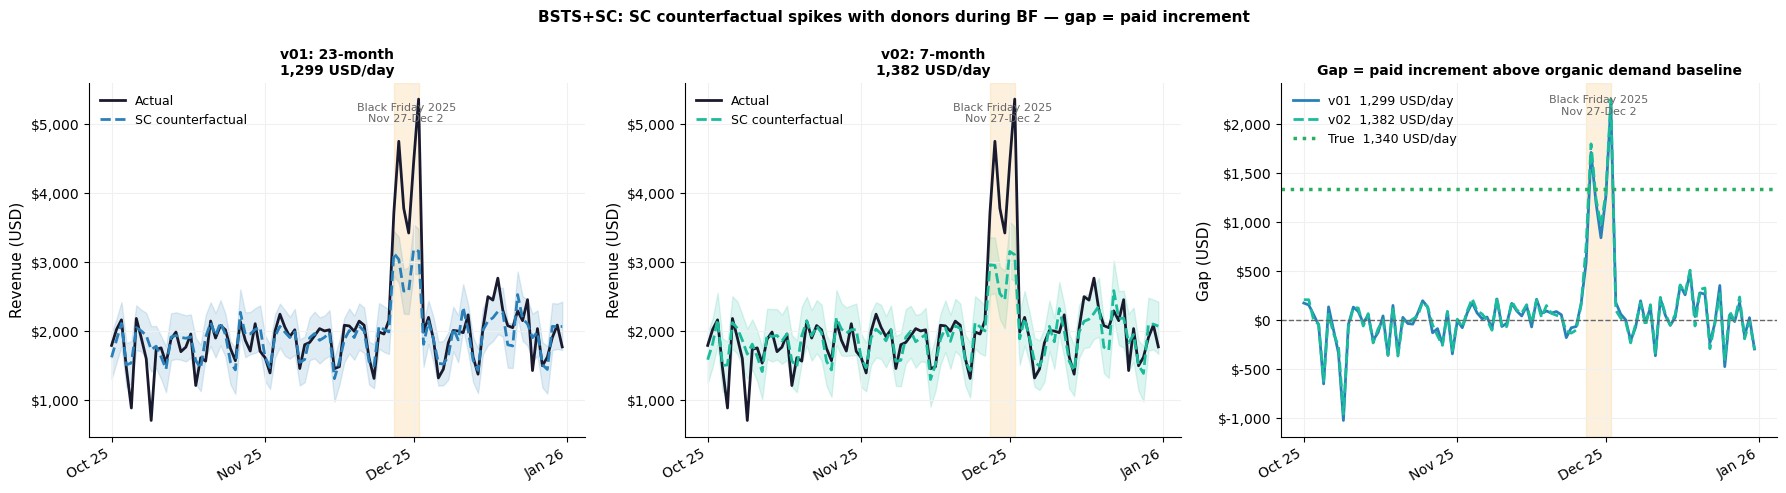

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, res, label, color in [
    (axes[0], res_v01, f'v01: 23-month\n{bf_v01["daily_effect"]:,.0f} USD/day', PALETTE['level3']),
    (axes[1], res_v02, f'v02: 7-month\n{bf_v02["daily_effect"]:,.0f} USD/day', '#1abc9c'),
]:
    zm = np.array(res.index >= '2025-10-01')
    zd = np.array(res.index[zm])
    ax.plot(zd, res['actual'].values[zm],    color=PALETTE['actual'], lw=2, label='Actual')
    ax.plot(zd, res['predicted'].values[zm], color=color, lw=2, ls='--', label='SC counterfactual')
    ax.fill_between(zd, res['lower_95'].values[zm], res['upper_95'].values[zm],
                    color=color, alpha=0.15)
    add_intervention_band(ax)
    format_date_axis(ax)
    ax.set_title(label, fontsize=10)
    ax.set_ylabel('Revenue (USD)')
    ax.yaxis.set_major_formatter(usd_formatter())
    ax.legend(fontsize=9)

# Panel 3: gap vs ground truth
zm1  = np.array(res_v01.index >= '2025-10-01')
zm2  = np.array(res_v02.index >= '2025-10-01')
zd1  = np.array(res_v01.index[zm1])
zd2  = np.array(res_v02.index[zm2])
gap1 = res_v01['actual'].values[zm1] - res_v01['predicted'].values[zm1]
gap2 = res_v02['actual'].values[zm2] - res_v02['predicted'].values[zm2]
bf1  = (pd.to_datetime(zd1) >= INTERVENTION_START) & (pd.to_datetime(zd1) <= INTERVENTION_END)
bf2  = (pd.to_datetime(zd2) >= INTERVENTION_START) & (pd.to_datetime(zd2) <= INTERVENTION_END)

axes[2].plot(zd1, gap1, color=PALETTE['level3'], lw=2,
             label=f'v01  {gap1[bf1].mean():,.0f} USD/day')
axes[2].plot(zd2, gap2, color='#1abc9c', lw=2, ls='--',
             label=f'v02  {gap2[bf2].mean():,.0f} USD/day')
axes[2].axhline(TRUE_DAILY, color=PALETTE['truth'], lw=2.5, ls=':',
                label=f'True  {TRUE_DAILY:,.0f} USD/day')
axes[2].axhline(0, color=PALETTE['annotation'], lw=1, ls='--')
add_intervention_band(axes[2])
format_date_axis(axes[2])
axes[2].set_title('Gap = paid increment above organic demand baseline', fontsize=10)
axes[2].set_ylabel('Gap (USD)')
axes[2].yaxis.set_major_formatter(usd_formatter())
axes[2].legend(fontsize=9)

plt.suptitle('BSTS+SC: SC counterfactual spikes with donors during BF — gap = paid increment',
             fontsize=11, fontweight='bold')
plt.tight_layout()
save_figure(fig, '03d_bsts_sc_results')
plt.show()

## 10. Covariate inclusion probabilities (Bayesian variable selection)

In [15]:
ro.r('''
incl <- colMeans(result_v01$impact$model$bsts.model$coefficients != 0)
incl <- sort(incl, decreasing=TRUE)
cat("Donor inclusion probabilities (v01):\n")
cat("(Higher = model relies more on this donor for the counterfactual)\n\n")
for (i in seq_along(incl)) {
    bar <- paste(rep("*", round(incl[i]*20)), collapse="")
    cat(sprintf("  %-25s %.2f  %s\n", names(incl)[i], incl[i], bar))
}
''')

Donor inclusion probabilities (v01):
(Higher = model relies more on this donor for the counterfactual)

  Organic_Search            1.00  ********************
  Direct                    1.00  ********************
  Referral                  1.00  ********************
  Social                    1.00  ********************
  (Intercept)               0.00  


## 11. Store results for notebook 04

In [16]:
print('=== Results summary ===')
print(f'Ground truth:    {TRUE_DAILY:,.0f} USD/day')
print(f'v01 (23-month):  {sc_v01_effect:,.0f} USD/day  ({(sc_v01_effect/TRUE_DAILY-1)*100:+.0f}%)')
print(f'v02 (7-month):   {sc_v02_effect:,.0f} USD/day  ({(sc_v02_effect/TRUE_DAILY-1)*100:+.0f}%)')
print()
print('Validation summary:')
print(f'  Pre-period MAPE v01: {diag_v01["mape"]:.1f}%')
print(f'  Pre-period MAPE v02: {diag_v02["mape"]:.1f}%')
print(f'  Placebo effect:      {plac_effect:+.0f} USD/day ({plac_pct:+.1f}%)')
print(f'  Max sensitivity swing: {max_swing:.0f}%')
print()
print('Copy sc_v01_effect and sc_v02_effect into notebook 04.')

=== Results summary ===
Ground truth:    1,340 USD/day
v01 (23-month):  1,299 USD/day  (-3%)
v02 (7-month):   1,382 USD/day  (+3%)

Validation summary:
  Pre-period MAPE v01: 10.0%
  Pre-period MAPE v02: 9.2%
  Placebo effect:      -103 USD/day (-5.4%)
  Max sensitivity swing: 17%

Copy sc_v01_effect and sc_v02_effect into notebook 04.


## Summary

BSTS+SC recovers the true paid increment on trend-shift data where BSTS alone fails.
The key mechanism: donor channels spike during BF at the actual 2025 level,
directly anchoring the counterfactual rather than relying on smoothed seasonal history.

**Validation results (synthetic data — expected to be optimistic):**
Pre-period MAPE well below threshold. Placebo effect near zero. Estimate
stable across donor variations. Credible interval excludes zero and contains
the true value. All four checks pass — as expected on clean synthetic data.
On real campaigns, these checks are not guaranteed.

**Key limitations:**
- 4 donor channels is thin; production analyses use 10-30+ units
- Donor exogeneity assumed — should be explicitly tested on real data
- Contemporaneous relationships assumed — test for lags in real campaigns
- Point estimates here; posterior credible intervals always accompany real analyses

---

**Next:** `04_maturity_ladder.ipynb` — all estimates vs. ground truth.